<table>
    <tr> 
    <th>                                                                                   
        <table>
            <tr>                                                                                   
                 <th  style="font-size:150%;ftext-align:left;background-color:#053061;color:white;">Valeur</th>
                 <th  style="font-size:150%;text-align:left;background-color:#053061;color:white;">Nom classe</th>
             </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">0</th>
                <th  style="font-size:150%;text-align:left">eosinophil</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">1</th>
                <th  style="font-size:150%;text-align:left">lymphocyte</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">2</th>
                <th  style="font-size:150%;text-align:left">monocyte</th>
            </tr>
            <tr>
                <th  style="font-size:150%;text-align:left">3</th>
                <th  style="font-size:150%;text-align:left">neutrophil</th>
            </tr>
        </table>
    </th>
    <th> 
        <div style='padding:15px;color:#030aa7;font-size:240%;text-align: center;font-style: italic;font-weight: bold;font-family: Georgia, serif'>BloodMNIST<br> Standardized Biomedical Images</div>
        <div style='text-align: center'>
            <img src="https://raw.githubusercontent.com/rbizoi/DeepLearning/refs/heads/main/images/bood-4.png" width="512">
        </div>      
    </th>
    </tr>
</table>

<div style='padding:15px;color:#030aa7;font-size:100%;text-align: left;font-family: Georgia, serif'><a href="https://www.kaggle.com/datasets/kylewang1999/pbc-dataset">Veuillez vous référer à la page officielle pour plus de détails.</a></div>

>> **site du projet** : https://data.mendeley.com/datasets/snkd93bnjr/1

>> **article** : https://doi.org/10.1016/j.cmpb.2019.105020

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Initialisation du document</div></b>

In [1]:
import os
# import json
# @param ["tensorflow", "jax", "torch"]
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ['KERAS_BACKEND'] = 'tensorflow'  
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'
os.environ['TF_CPP_MIN_LOG_LEVEL']='5'

import tensorflow as tf
import keras
tf.get_logger().setLevel('ERROR')

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Import libriries </div></b>

In [2]:
import numpy as np, pandas as pd, seaborn as sns, warnings, os, sys, time
from matplotlib import pyplot as plt

warnings.filterwarnings(action="ignore")

if int(str(sns.__version__).split('.')[1]) > 8 : 
    plt.style.use('seaborn-v0_8-darkgrid')
else:
    plt.style.use('seaborn-darkgrid')
    
sns.set(font_scale=2)

print(f"""La version des librairies utilisées :

Tensorflow : {tf.__version__}\tCUDA {tf.test.is_built_with_cuda()}\tGPU {tf.test.is_built_with_gpu_support()}\tXLA {tf.test.is_built_with_xla()}
Keras      : {keras.version()}
Pandas     : {pd.__version__}
NumPy      : {np.__version__}""")

La version des librairies utilisées :

Tensorflow : 2.16.1	CUDA True	GPU True	XLA True
Keras      : 3.1.1
Pandas     : 2.2.1
NumPy      : 1.26.4


# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Outils du document</div></b>

In [3]:
sys.path.append(os.path.abspath('../outils/'))

In [4]:
if 'configProjet' in sys.modules.keys():  del(sys.modules['configProjet'])
if 'configModele' in sys.modules.keys():  del(sys.modules['configModele'])

In [5]:
from configProjet import palette, initParametresProjet 
from configProjet import afficheHistoriqueEntrainement, afficheProbabilites, afficheMatriceConfusion, afficheDataset, afficheDistributionsPipe

In [ ]:
from configModele import modelDictionnaire, initParametresExecution, getPipelineDataset
from configModele import creationCompilationModele, creationRappelsExecution, entrainementModele
from configModele import sauvegarderModel, sauvegardeHistorique, executeApprentissageChoixClassifieurs
from configModele import modelCNNSimple, modelPersonalise, modelPersonaliseInception

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Paramétrés de l’exécution et les flux de lecture des fichiers TFRecors</div></b>

In [7]:
image_size,batch_size,epochs,dictLabels,nombreClasses,pipelineApprentissage,pipelineValidation = \
       initParametresExecution(image_size=(160, 160, 3),
                            batch_size = 32,
                            epochs=128,
                            repertoire='../donnees/BloodMNIST224x224-4',
                            cycle_length=None,
                            deterministic=None,
                            repetition=1,
                            bufferAleatoire=1024)

In [8]:
print(f"""
  image_size    = {image_size}
  batch_size    = {batch_size}
  epochs        = {epochs}
  nombreClasses = {nombreClasses}
  dictLabels    = {dictLabels}
       """)


  image_size    = (160, 160, 3)
  batch_size    = 32
  epochs        = 128
  nombreClasses = 4
  dictLabels    = {0: 'eosinophil', 1: 'lymphocyte', 2: 'monocyte', 3: 'neutrophil'}
       


# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Affichage données</div></b>

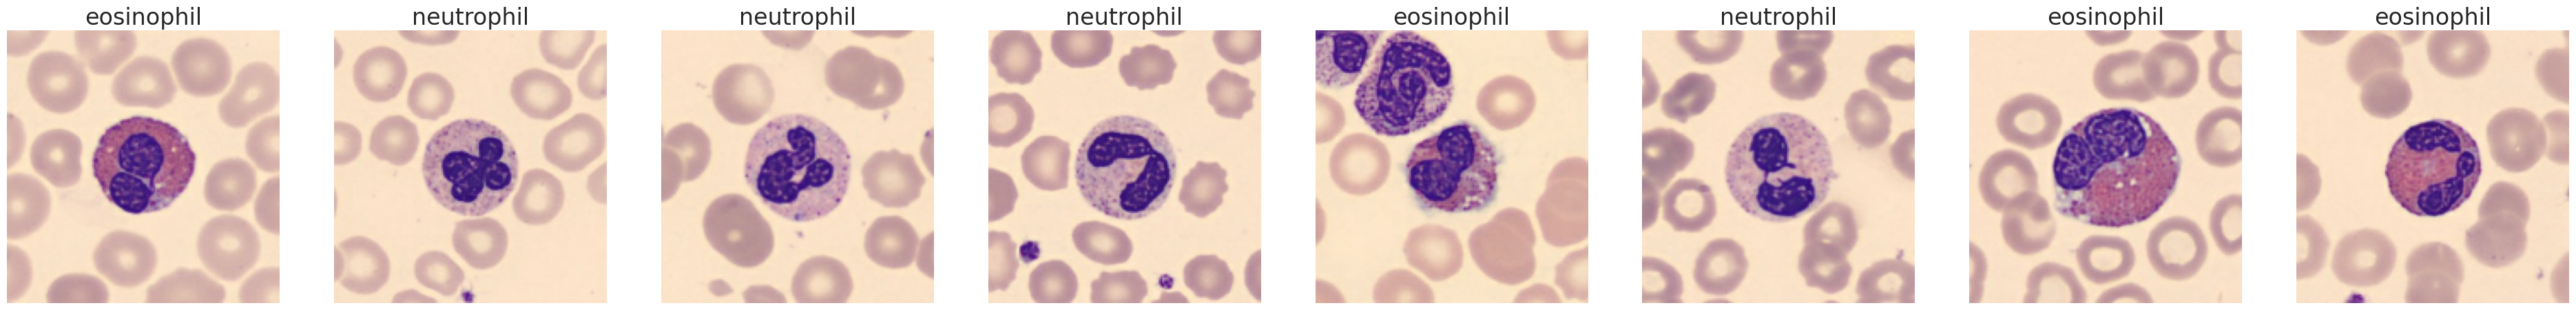

In [9]:
images, labels = next(iter(pipelineApprentissage))
nombresImages = 8
afficheDataset(images, labels,nombresImages,6*nombresImages,dictLabels,cmap=None)

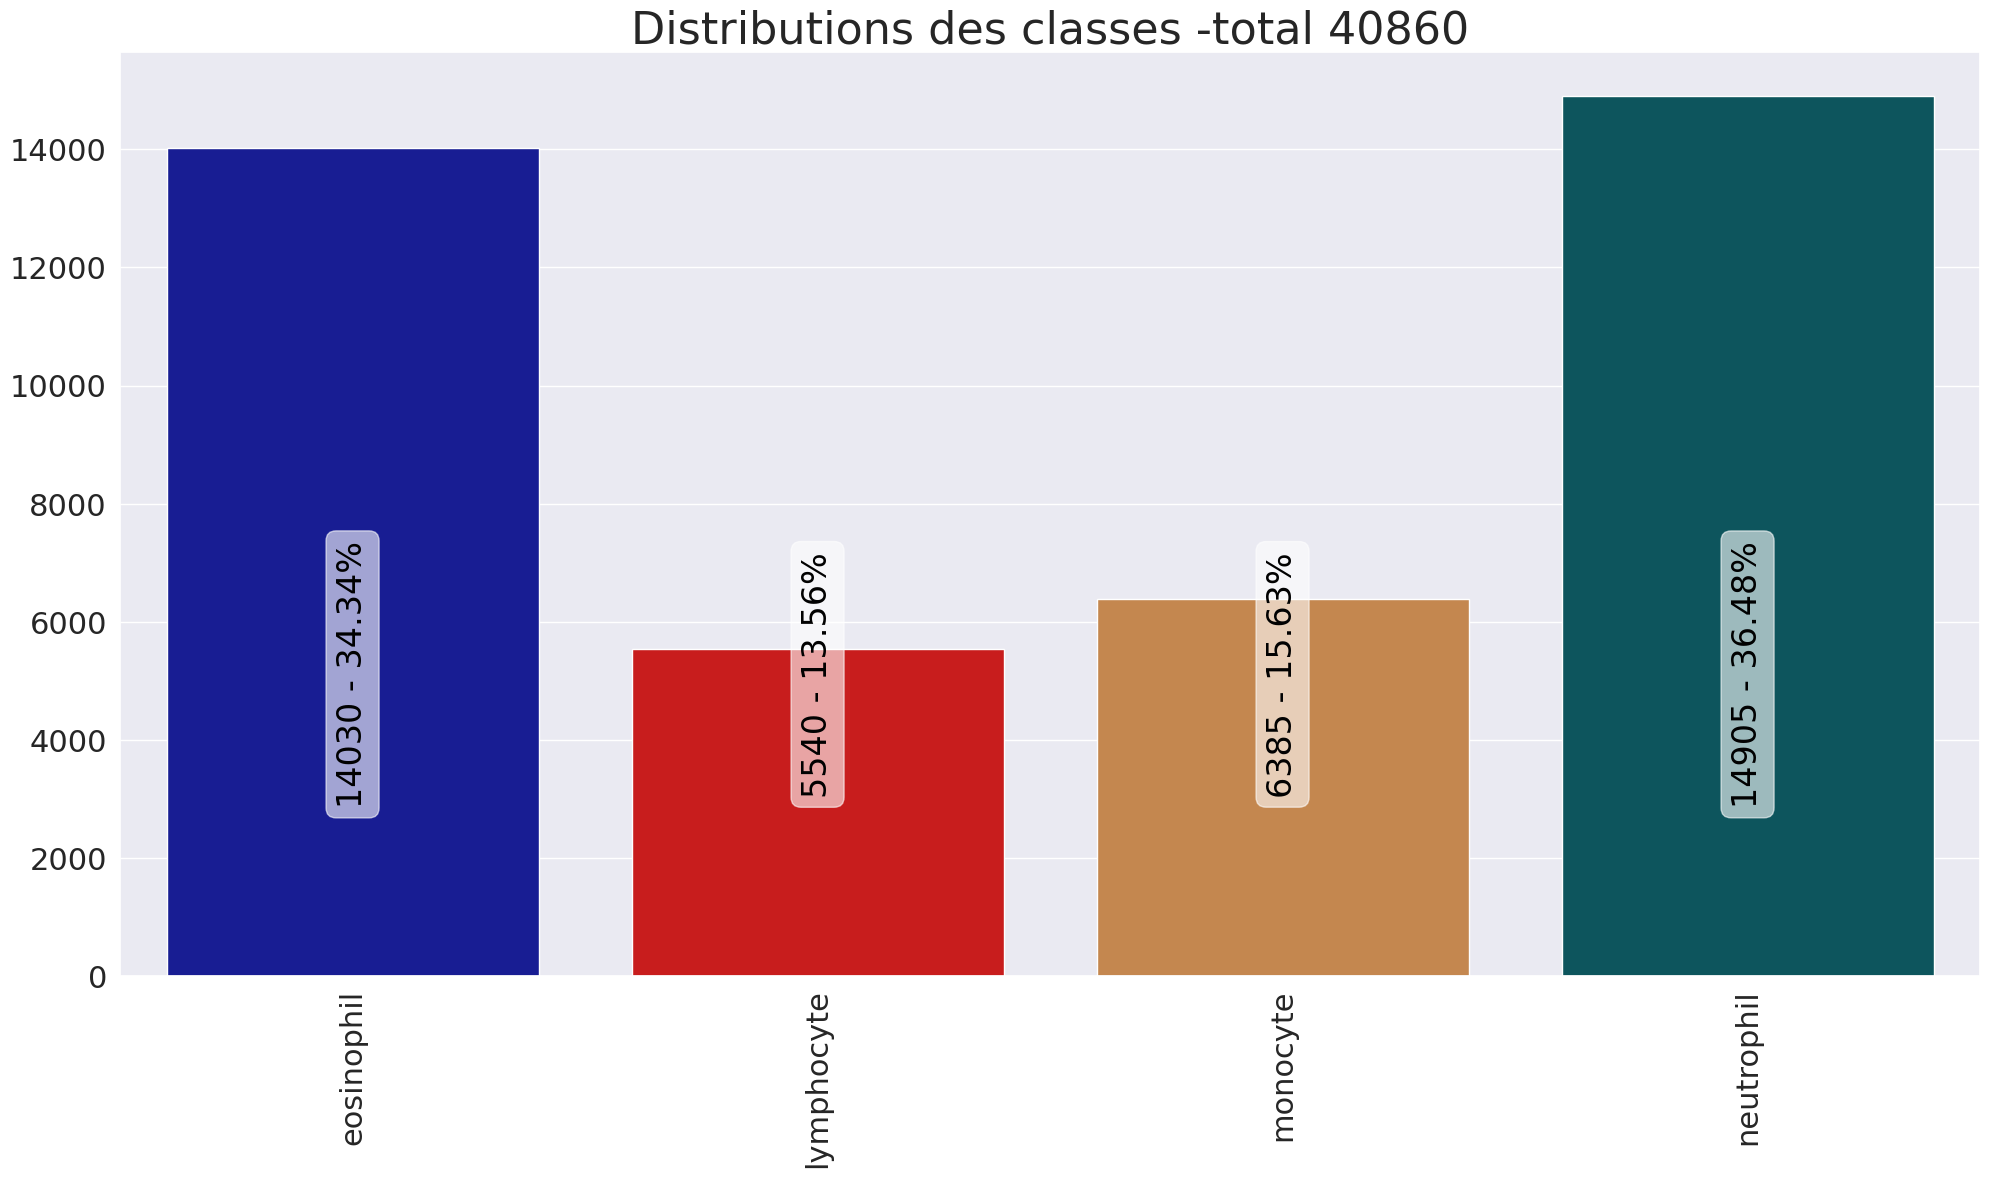

In [10]:
afficheDistributionsPipe(pipelineApprentissage, dictLabels, palette, repertoireEnregistrement=None)

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Choix du modèle</div></b>
             
<table>
    <tr>                                                                                   
         <th  style="font-size:150%;ftext-align:left;background-color:#053061;color:white;">Nom</th>
         <th  style="font-size:150%;text-align:left;background-color:#053061;color:white;">Description</th>
         <th  style="font-size:150%;text-align:left;background-color:#053061;color:white;">Référence</th>
     </tr>
    <tr>
        <th  style="font-size:130%;text-align:left">VGG19</th>
        <th  style="font-size:130%;text-align:left">Very Deep Convolutional Networks for Large-Scale Image Recognition (ICLR 2015)</th>
        <th  style="font-size:130%;text-align:left"><a href="https://arxiv.org/pdf/1409.1556">https://arxiv.org/pdf/1409.1556</a> </th>
    </tr>
    <tr>
        <th  style="font-size:130%;text-align:left">ResNet152V2</th>
        <th  style="font-size:130%;text-align:left">Identity Mappings in Deep Residual Networks (CVPR 2016)</th>
        <th  style="font-size:130%;text-align:left"><a href="https://arxiv.org/pdf/1603.05027">https://arxiv.org/pdf/1603.05027</a> </th>
    </tr>
    <tr>
        <th  style="font-size:130%;text-align:left">InceptionV3</th>
        <th  style="font-size:130%;text-align:left">Rethinking the Inception Architecture for Computer Vision (CVPR 2016)</th>
        <th  style="font-size:130%;text-align:left"><a href="https://arxiv.org/pdf/1512.00567">https://arxiv.org/pdf/1512.00567</a> </th>
    </tr>
    <tr>
        <th  style="font-size:130%;text-align:left">Xception</th>
        <th  style="font-size:130%;text-align:left">Deep Learning with Depthwise Separable Convolutions (CVPR 2017)</th>
        <th  style="font-size:130%;text-align:left"><a href="https://arxiv.org/pdf/1610.02357">https://arxiv.org/pdf/1610.02357</a> </th>
    </tr>
    <tr>
        <th  style="font-size:130%;text-align:left">InceptionResNetV2</th>
        <th  style="font-size:130%;text-align:left">Inception-v4, Inception-ResNet and the Impact of Residual Connections on Learning (AAAI 2017)</th>
        <th  style="font-size:130%;text-align:left"><a href="https://arxiv.org/pdf/1602.07261">https://arxiv.org/pdf/1602.07261</a> </th>
    </tr>    
    <tr>
        <th  style="font-size:130%;text-align:left">DenseNet201</th>
        <th  style="font-size:130%;text-align:left">Densely Connected Convolutional Networks (CVPR 2017)</th>
        <th  style="font-size:130%;text-align:left"><a href="https://arxiv.org/pdf/1608.06993">https://arxiv.org/pdf/1608.06993</a> </th>
    </tr>
    <tr>
        <th  style="font-size:130%;text-align:left">MobileNetV3Small</th>
        <th  style="font-size:130%;text-align:left">Inverted Residuals and Linear Bottlenecks (CVPR 2018)</th>
        <th  style="font-size:130%;text-align:left"><a href="https://arxiv.org/pdf/1801.04381">https://arxiv.org/pdf/1801.04381</a> </th>
    </tr>
    <tr>
        <th  style="font-size:130%;text-align:left">EfficientNet</th>
        <th  style="font-size:130%;text-align:left">Rethinking Model Scaling for Convolutional Neural Networks (ICML 2019)</th>
        <th  style="font-size:130%;text-align:left"><a href="https://arxiv.org/pdf/1905.11946">https://arxiv.org/pdf/1905.11946</a> </th>
    </tr>
    <tr>
        <th  style="font-size:130%;text-align:left">EfficientNetV2</th>
        <th  style="font-size:130%;text-align:left">Smaller Models and Faster Training (ICML 2021)</th>
        <th  style="font-size:130%;text-align:left"><a href="https://arxiv.org/pdf/2104.00298">https://arxiv.org/pdf/2104.00298</a> </th>
    </tr>    
    <tr>
        <th  style="font-size:130%;text-align:left">ConvNeXtSmall</th>
        <th  style="font-size:130%;text-align:left">A ConvNet for the 2020s (CVPR 2022)</th>
        <th  style="font-size:130%;text-align:left"><a href="https://arxiv.org/pdf/2201.03545">https://arxiv.org/pdf/2201.03545</a> </th>
    </tr>    
</table>


In [11]:
print('Choisissez un des noms dans la liste suivante :')
for nom in modelDictionnaire : print(nom, end=' \t')

Choisissez un des noms dans la liste suivante :
ResNet152V2 	DenseNet201 	Xception 	InceptionV3 	InceptionResNetV2 	MobileNetV3Small 	EfficientNetV2S 	ConvNeXtSmall 	

In [12]:
nomModel = 'MobileNetV3Small'

In [13]:
repertoireEnregistrement,repertoireSauvegardes,repertoireModelCKP,repertoireModelSauvegarde,repertoireModelLogs = \
            initParametresProjet(nomProjet=f"5-bloodMNIST-{nomModel}-160x160-bs{batch_size:02d}-epochs{epochs:03d}",repertoireProjet='../ResultatsExecutions')

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Création et compilation d'un modèle</div></b>

In [14]:
model = creationCompilationModele( nomModel, 
                                   modelDictionnaire, 
                                   image_size, 
                                   nombreClasses)

In [15]:
model.summary()

Model: "MobileNetV3Small_blood"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobilenetV3small (Functional)   │ (None, 5, 5, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ couche_prob (Dense)             │ (None, 4)              │         2,308 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 941,428 (3.59 MB)

 Trainable params: 929,316 (3.55 MB)

 Non-trainable params: 12,112 (47.31 KB)

In [16]:
model.compile(
        optimizer=keras.optimizers.AdamW(1e-03), 
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy')],
    )

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Rappels d’exécution (callbacks)</div></b>

In [17]:
callbacks = creationRappelsExecution(repertoireModelSauvegarde,
                                     repertoireModelCKP,
                                     repertoireModelLogs,
                                     patienceArretPrecoce=8,
                                     initial_lrate=1e-03,
                                     max_lrate=1e-03,
                                     min_lrate=1e-05,
                                     epochs_runup_lrate=0,
                                     epochs_sustain_lrate=0,
                                     drop_lrate=0.98)

# <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Evolution du taux d'apprentissage</div></b>

In [18]:
def evolutionTauxApprentissage(epoch,
                               initial_lrate=1e-03,
                               max_lrate=1e-03,
                               min_lrate=1e-05,
                               epochs_runup_lrate=0,
                               epochs_sustain_lrate=0,
                               drop_lrate=0.98):
    # epochs_drop = epochs * 0.1
    if epoch < epochs_runup_lrate:
        lrate = (max_lrate - initial_lrate) / epochs_runup_lrate * epoch + initial_lrate
    elif epoch < epochs_runup_lrate + epochs_sustain_lrate:
        lrate = max_lrate
    else:
        lrate = (max_lrate - min_lrate) * drop_lrate**(epoch - epochs_runup_lrate - epochs_sustain_lrate) + min_lrate
    return lrate

L'évolution du taux d'apprentissage : du 0.001 à 8.61e-05


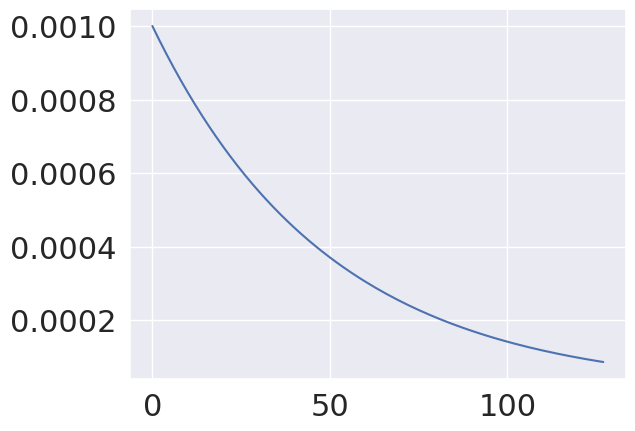

In [19]:
rng = [i for i in range(epochs)]
y = [evolutionTauxApprentissage(x) for x in rng]
plt.plot(rng, y)

print(f"L'évolution du taux d'apprentissage : du {y[0]:.3g} à {min(y):.3g}")

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Entrainement du modèle</div></b>


In [20]:
historiqueApprentissage, model = entrainementModele( model, 
                                                     pipelineApprentissage,
                                                     pipelineValidation, 
                                                     epochs, 
                                                     batch_size,
                                                     callbacks,
                                                     2, #verbose=2, 
                                                     repertoireModelSauvegarde)

I0000 00:00:1757231322.384177   24525 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_8298', 116 bytes spill stores, 116 bytes spill loads

I0000 00:00:1757231322.394466   24501 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_8298', 348 bytes spill stores, 348 bytes spill loads

I0000 00:00:1757231334.522047   24721 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_1321', 92 bytes spill stores, 92 bytes spill loads




Epoch 1: val_loss improved from inf to 1.29812, saving model to ../ResultatsExecutions/5-bloodMNIST-MobileNetV3Small-160x160-bs32-epochs128/model.sauvegardes/sauvegarde/modelVLoss.keras
1277/1277 - 55s - 43ms/step - accuracy: 0.9641 - loss: 0.1046 - val_accuracy: 0.3833 - val_loss: 1.2981 - learning_rate: 0.0010
Epoch 2/128

Epoch 2: val_loss did not improve from 1.29812
1277/1277 - 12s - 9ms/step - accuracy: 0.9880 - loss: 0.0381 - val_accuracy: 0.3833 - val_loss: 1.7835 - learning_rate: 9.8020e-04
Epoch 3/128

Epoch 3: val_loss did not improve from 1.29812
1277/1277 - 12s - 9ms/step - accuracy: 0.9908 - loss: 0.0285 - val_accuracy: 0.3833 - val_loss: 13.6382 - learning_rate: 9.6080e-04
Epoch 4/128

Epoch 4: val_loss did not improve from 1.29812
1277/1277 - 12s - 9ms/step - accuracy: 0.9930 - loss: 0.0236 - val_accuracy: 0.6564 - val_loss: 3.0568 - learning_rate: 9.4178e-04
Epoch 5/128

Epoch 5: val_loss improved from 1.29812 to 0.20536, saving model to ../ResultatsExecutions/5-blood

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Affichage historique de l'apprentissage </div></b>

In [21]:
historique = sauvegardeHistorique(historiqueApprentissage,
                                  repertoireSauvegardes,
                                  nomSauvegarde=f'historique-{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}')

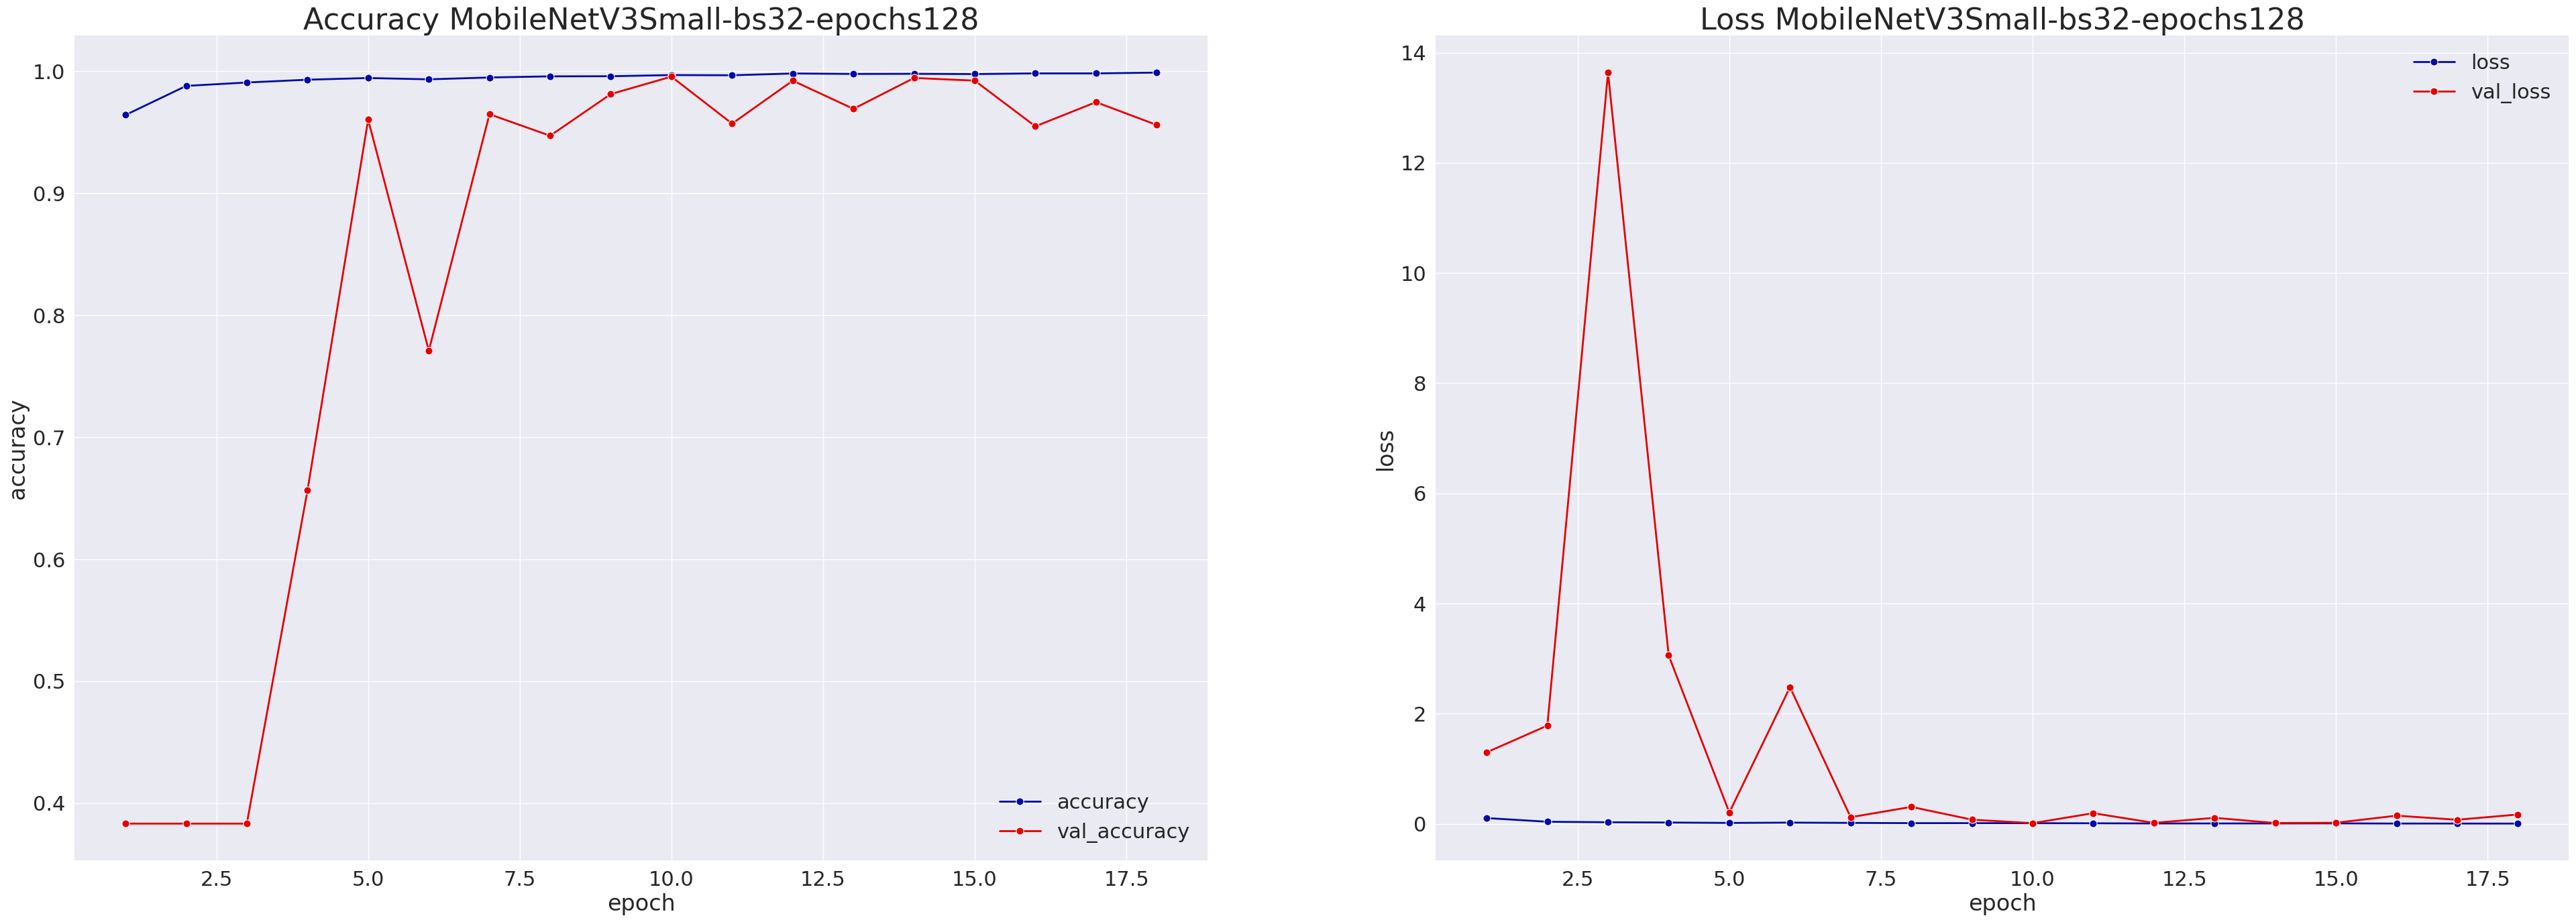

In [22]:
afficheHistoriqueEntrainement(historique, palette, f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}', repertoireEnregistrement)

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Sauvegarde du modèle </div></b>

In [23]:
model.save(os.path.join(repertoireModelSauvegarde,f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}.keras'))

# <b><div style='padding:18px;background-color:#d8dcd6;color:#030aa7;font-size:130%; border-radius:12px 12px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Inférence</div></b>

In [24]:
for i, (img,lab) in enumerate(pipelineValidation): 
    images = img if i==0 else tf.concat([images,img], 0)   
    labels = lab if i==0 else tf.concat([labels,lab], 0)

In [25]:
probabilities = model.predict(images, verbose=0)
predictions = np.argmax(probabilities, axis=-1)

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Probabilités pour les 8 premiers prédictions </div></b>

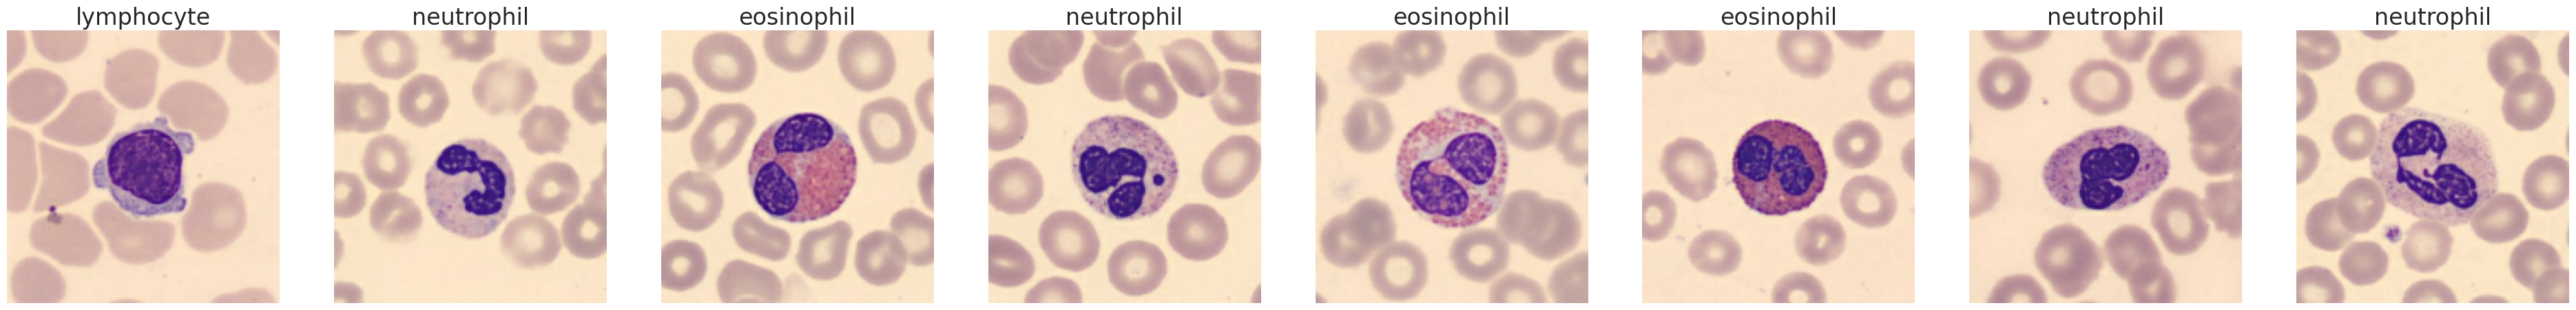

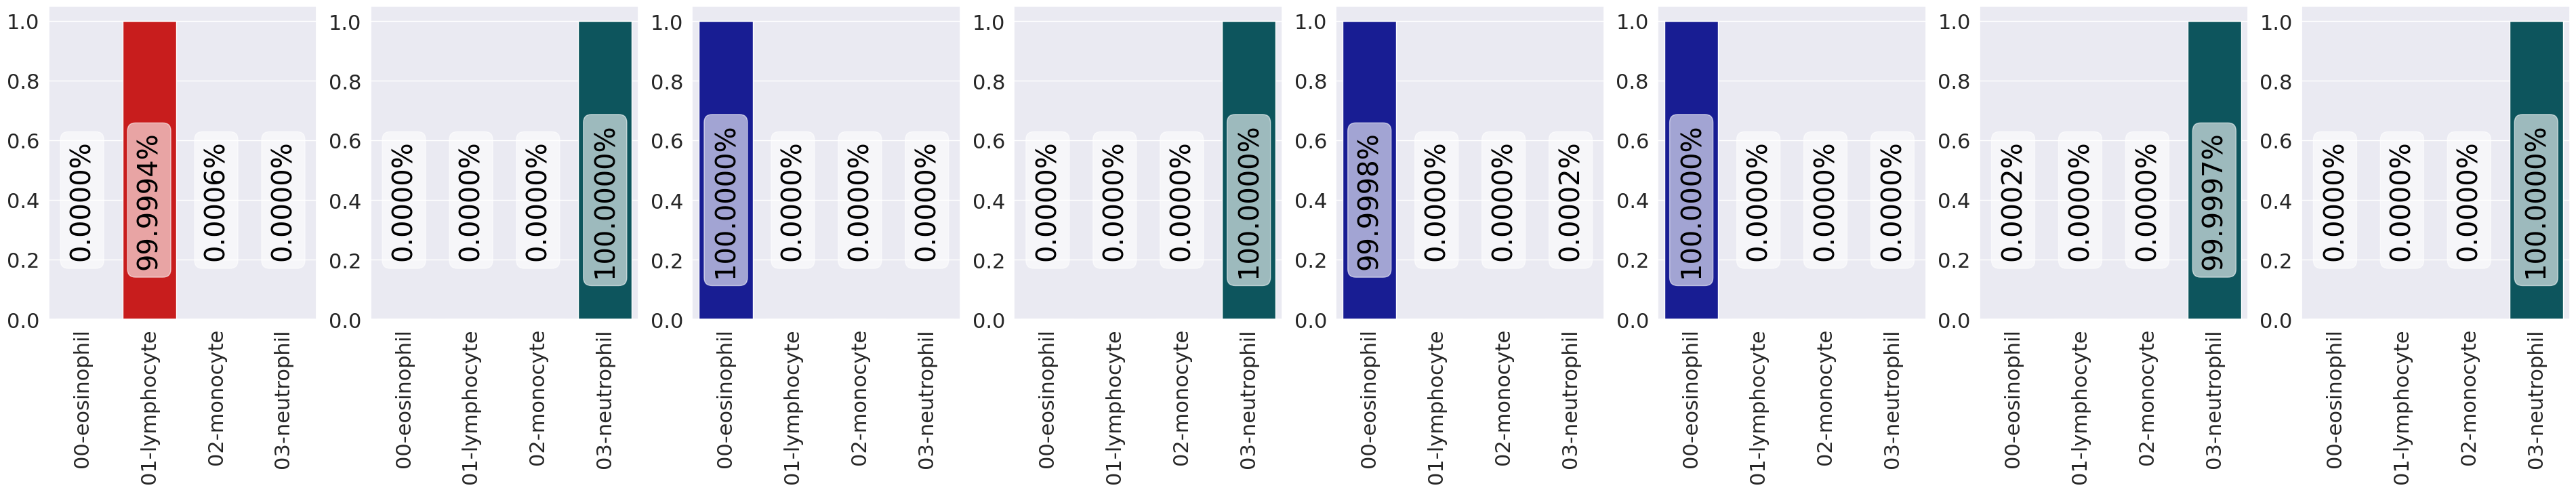

In [26]:
nombresImages = 8
afficheDataset(images, labels,nombresImages,6*nombresImages,dictLabels,cmap=None)
fig, ax = plt.subplots(nrows=1, ncols=nombresImages,figsize=(6*nombresImages,6));
for i in range(nombresImages):
    afficheProbabilites(probabilities,ind=i,ax=ax[i], dictLabels=dictLabels)

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Matrice de Confusion </div></b>

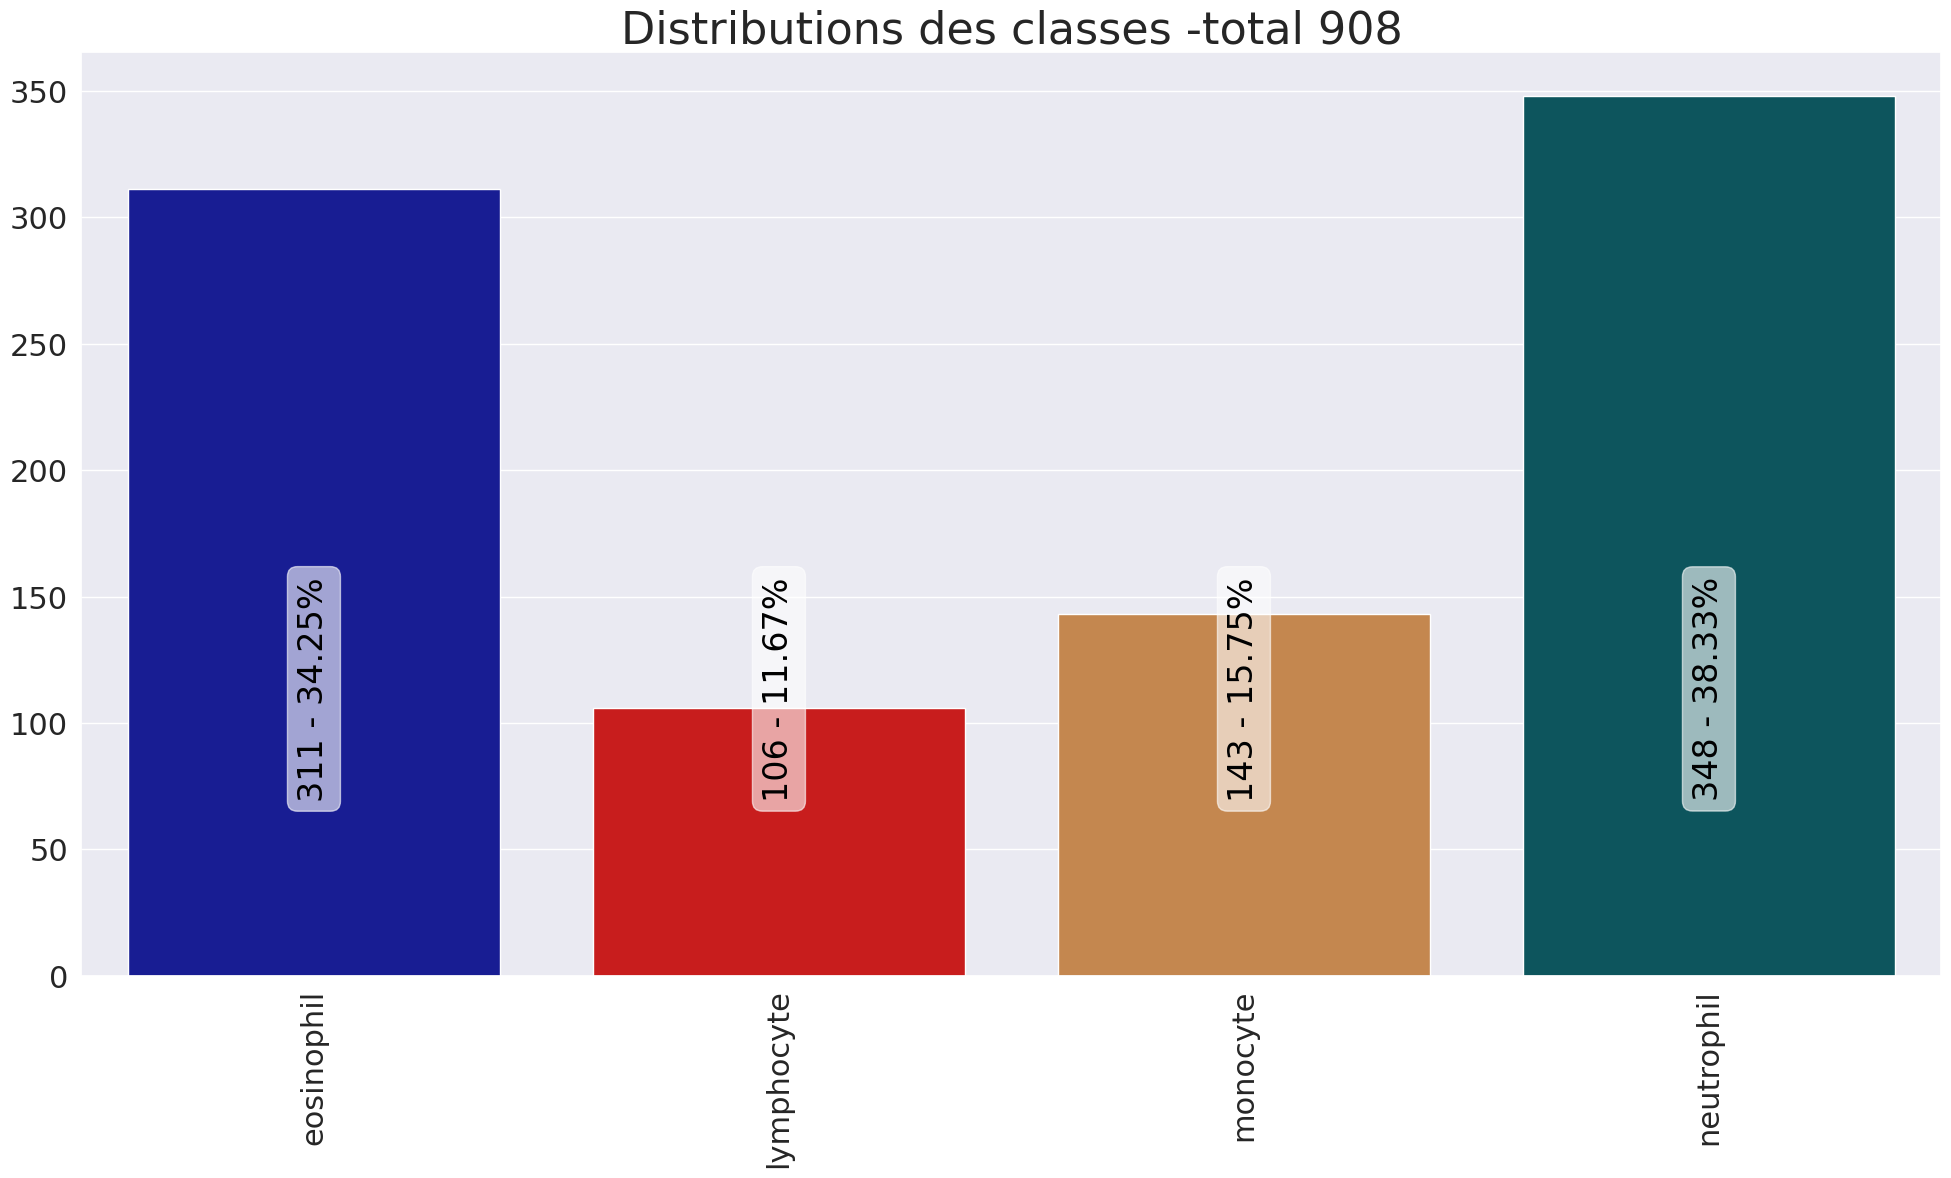

In [27]:
afficheDistributionsPipe(pipelineValidation, dictLabels, palette, repertoireEnregistrement=None)

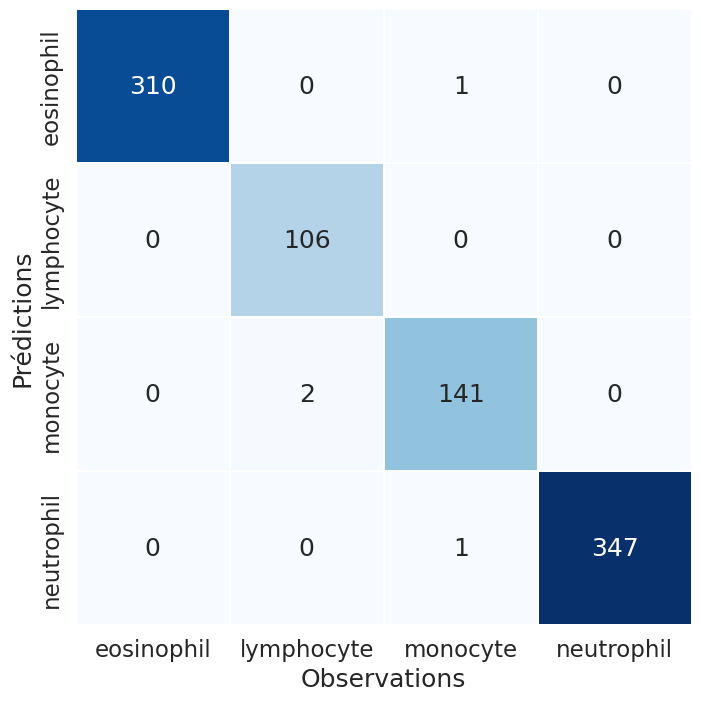

In [28]:
afficheMatriceConfusion(observations=labels,predictions=predictions,dictLabels=dictLabels, repertoireEnregistrement=repertoireEnregistrement,
                        nom_essai = f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}')

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:100%; border-radius:10px 10px; box-shadow: 8px 8px 8px #042b4c;text-align: left'>Résultats de l’apprentissage</div></b>

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Area under the ROC curve : 1.0000	--	Exécution  :4.87s


,Classe,aucROC,avgPrecRec,f1,f2,f05,accuracy,precision,sensibilite,vrais_positifs,vrais_negatifs,faux_positifs,faux_negatifs,total_positifs,essai
0,global,0.999976,0.999923,0.995603,0.995595,0.995620,0.995595,0.995636,0.995595,904,2720,4,4,908,MobileNetV3Small-bs32-epochs128
1,eosinophil,1.000000,1.000000,0.998390,0.997426,0.999355,0.998899,1.000000,0.996785,310,597,0,1,311,MobileNetV3Small-bs32-epochs128
2,lymphocyte,1.000000,1.000000,0.990654,0.996241,0.985130,0.997797,0.981481,1.000000,106,800,2,0,106,MobileNetV3Small-bs32-epochs128
3,monocyte,0.999909,0.999515,0.986014,0.986014,0.986014,0.995595,0.986014,0.986014,141,763,2,2,143,MobileNetV3Small-bs32-epochs128
4,neutrophil,0.999995,0.999992,0.998561,0.997700,0.999424,0.998899,1.000000,0.997126,347,560,0,1,348,MobileNetV3Small-bs32-epochs128


<Figure size 1800x1800 with 0 Axes>

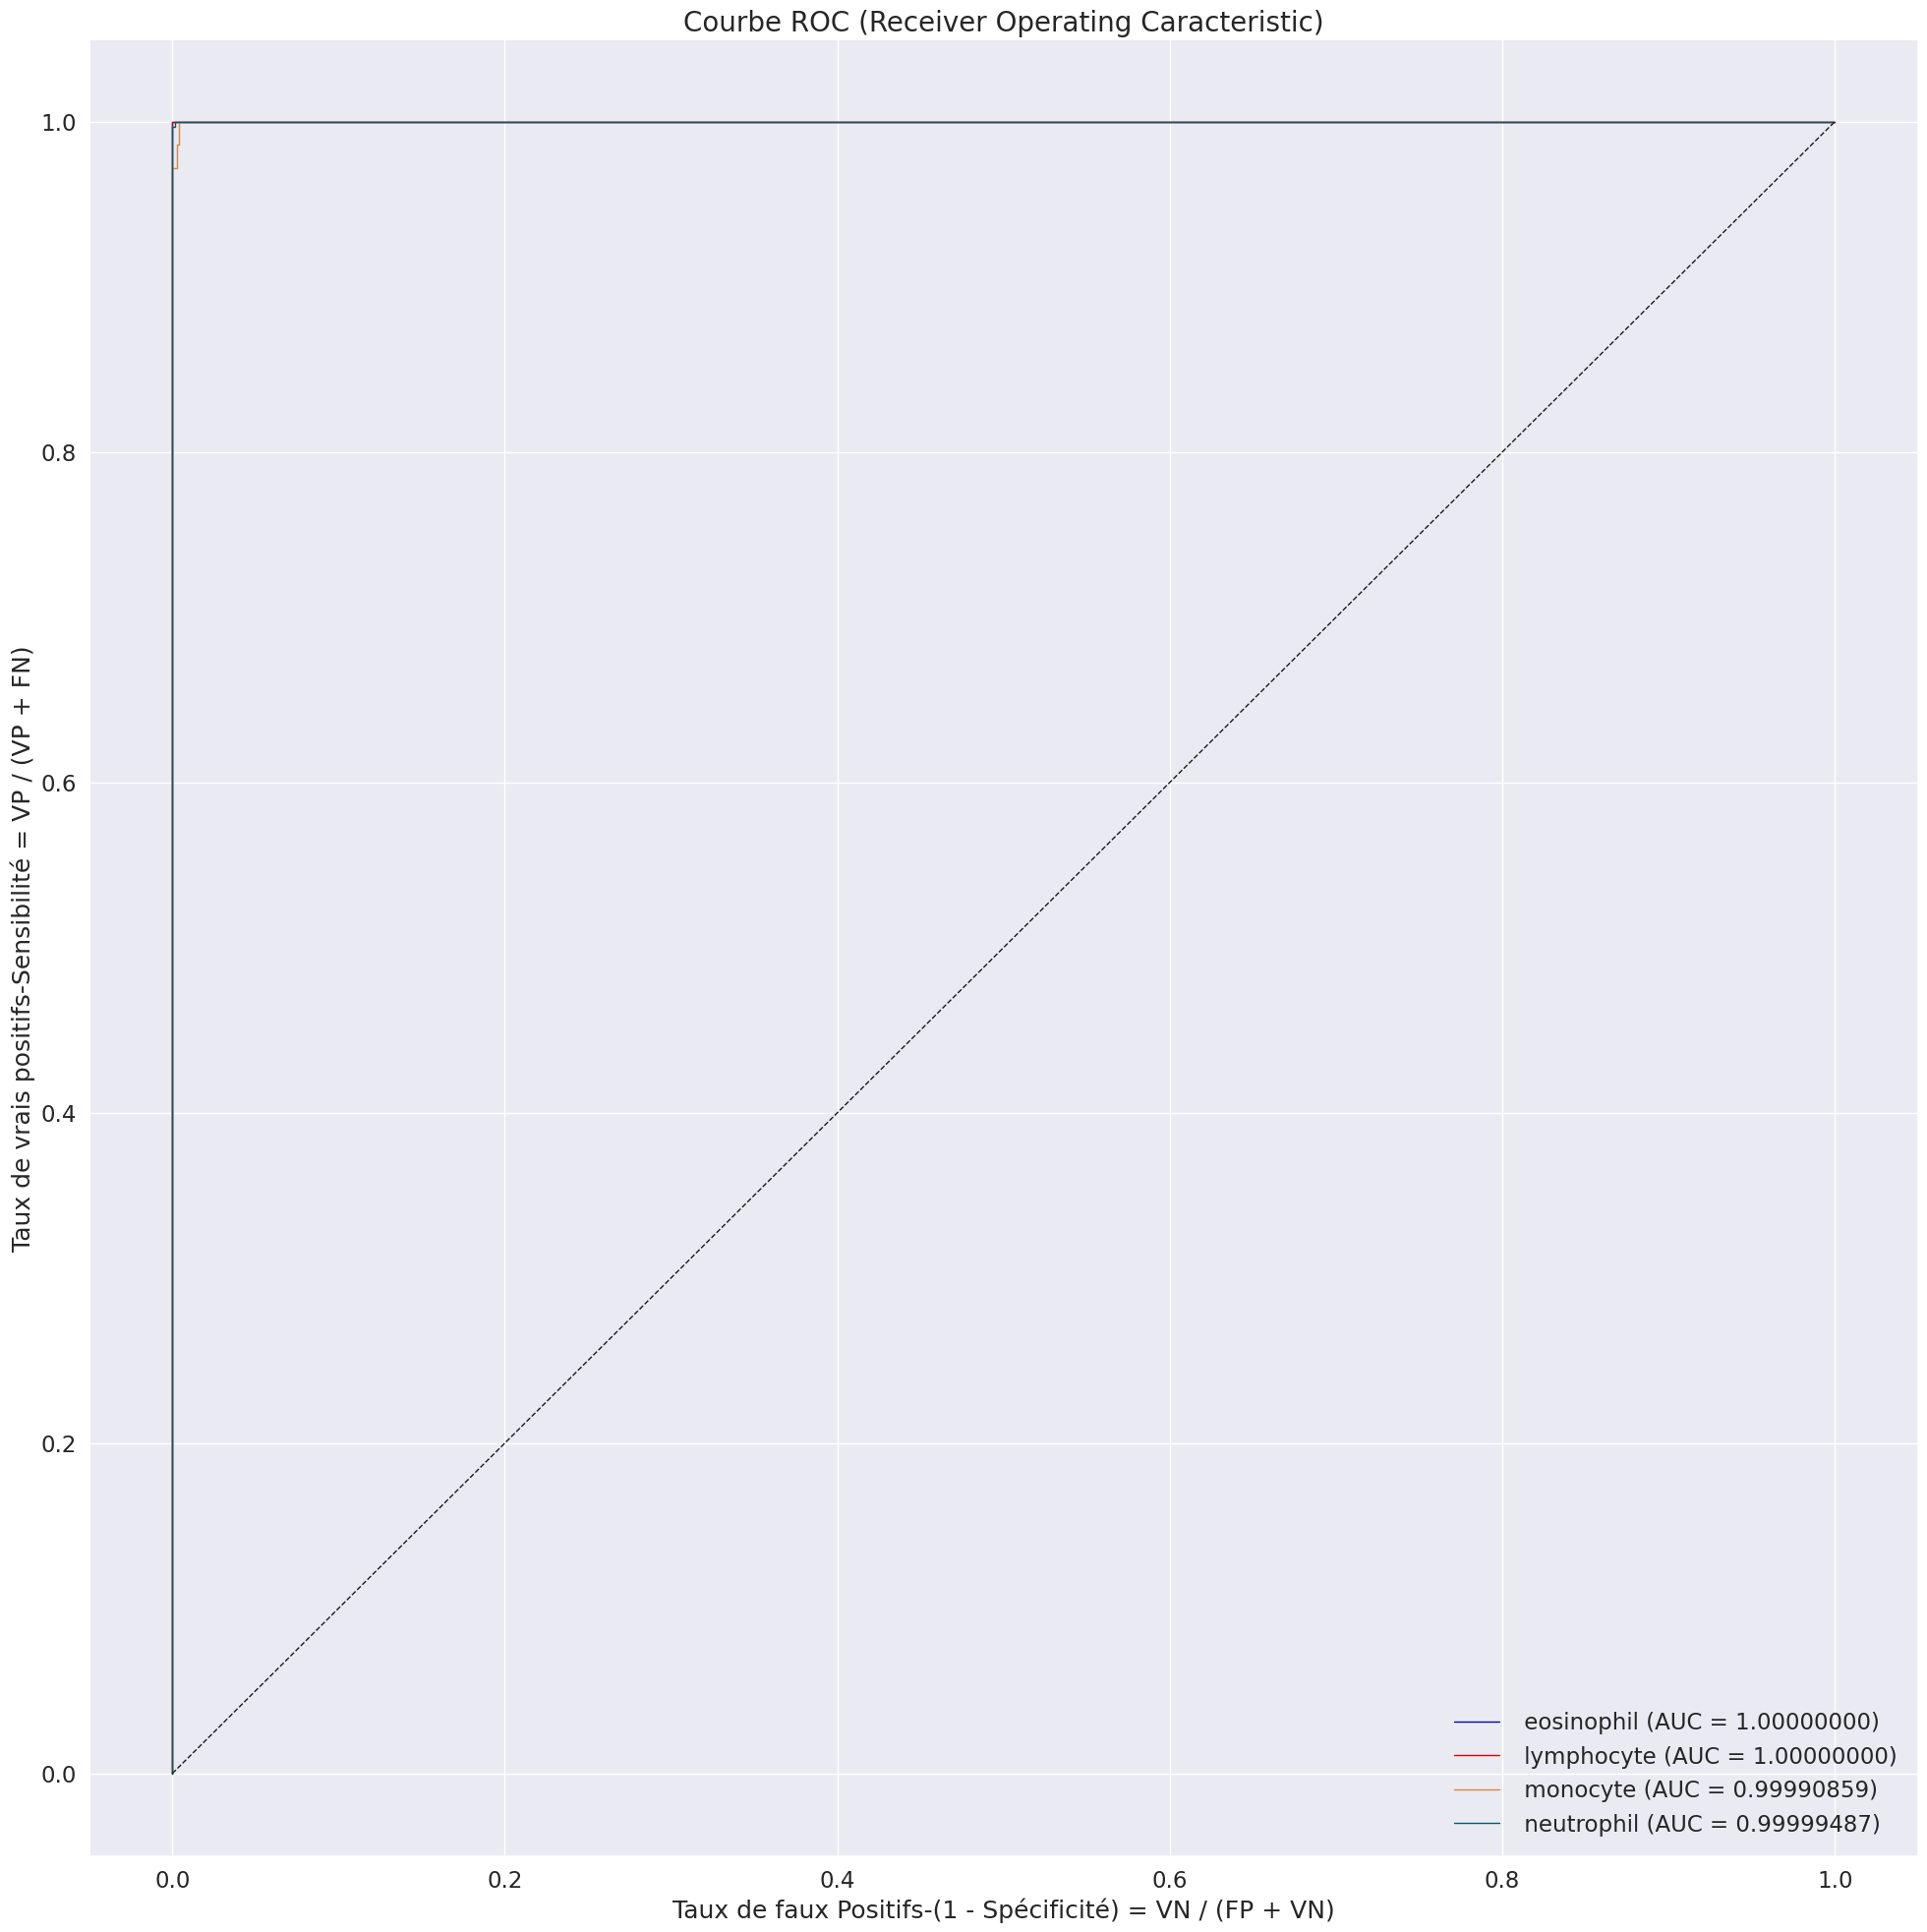

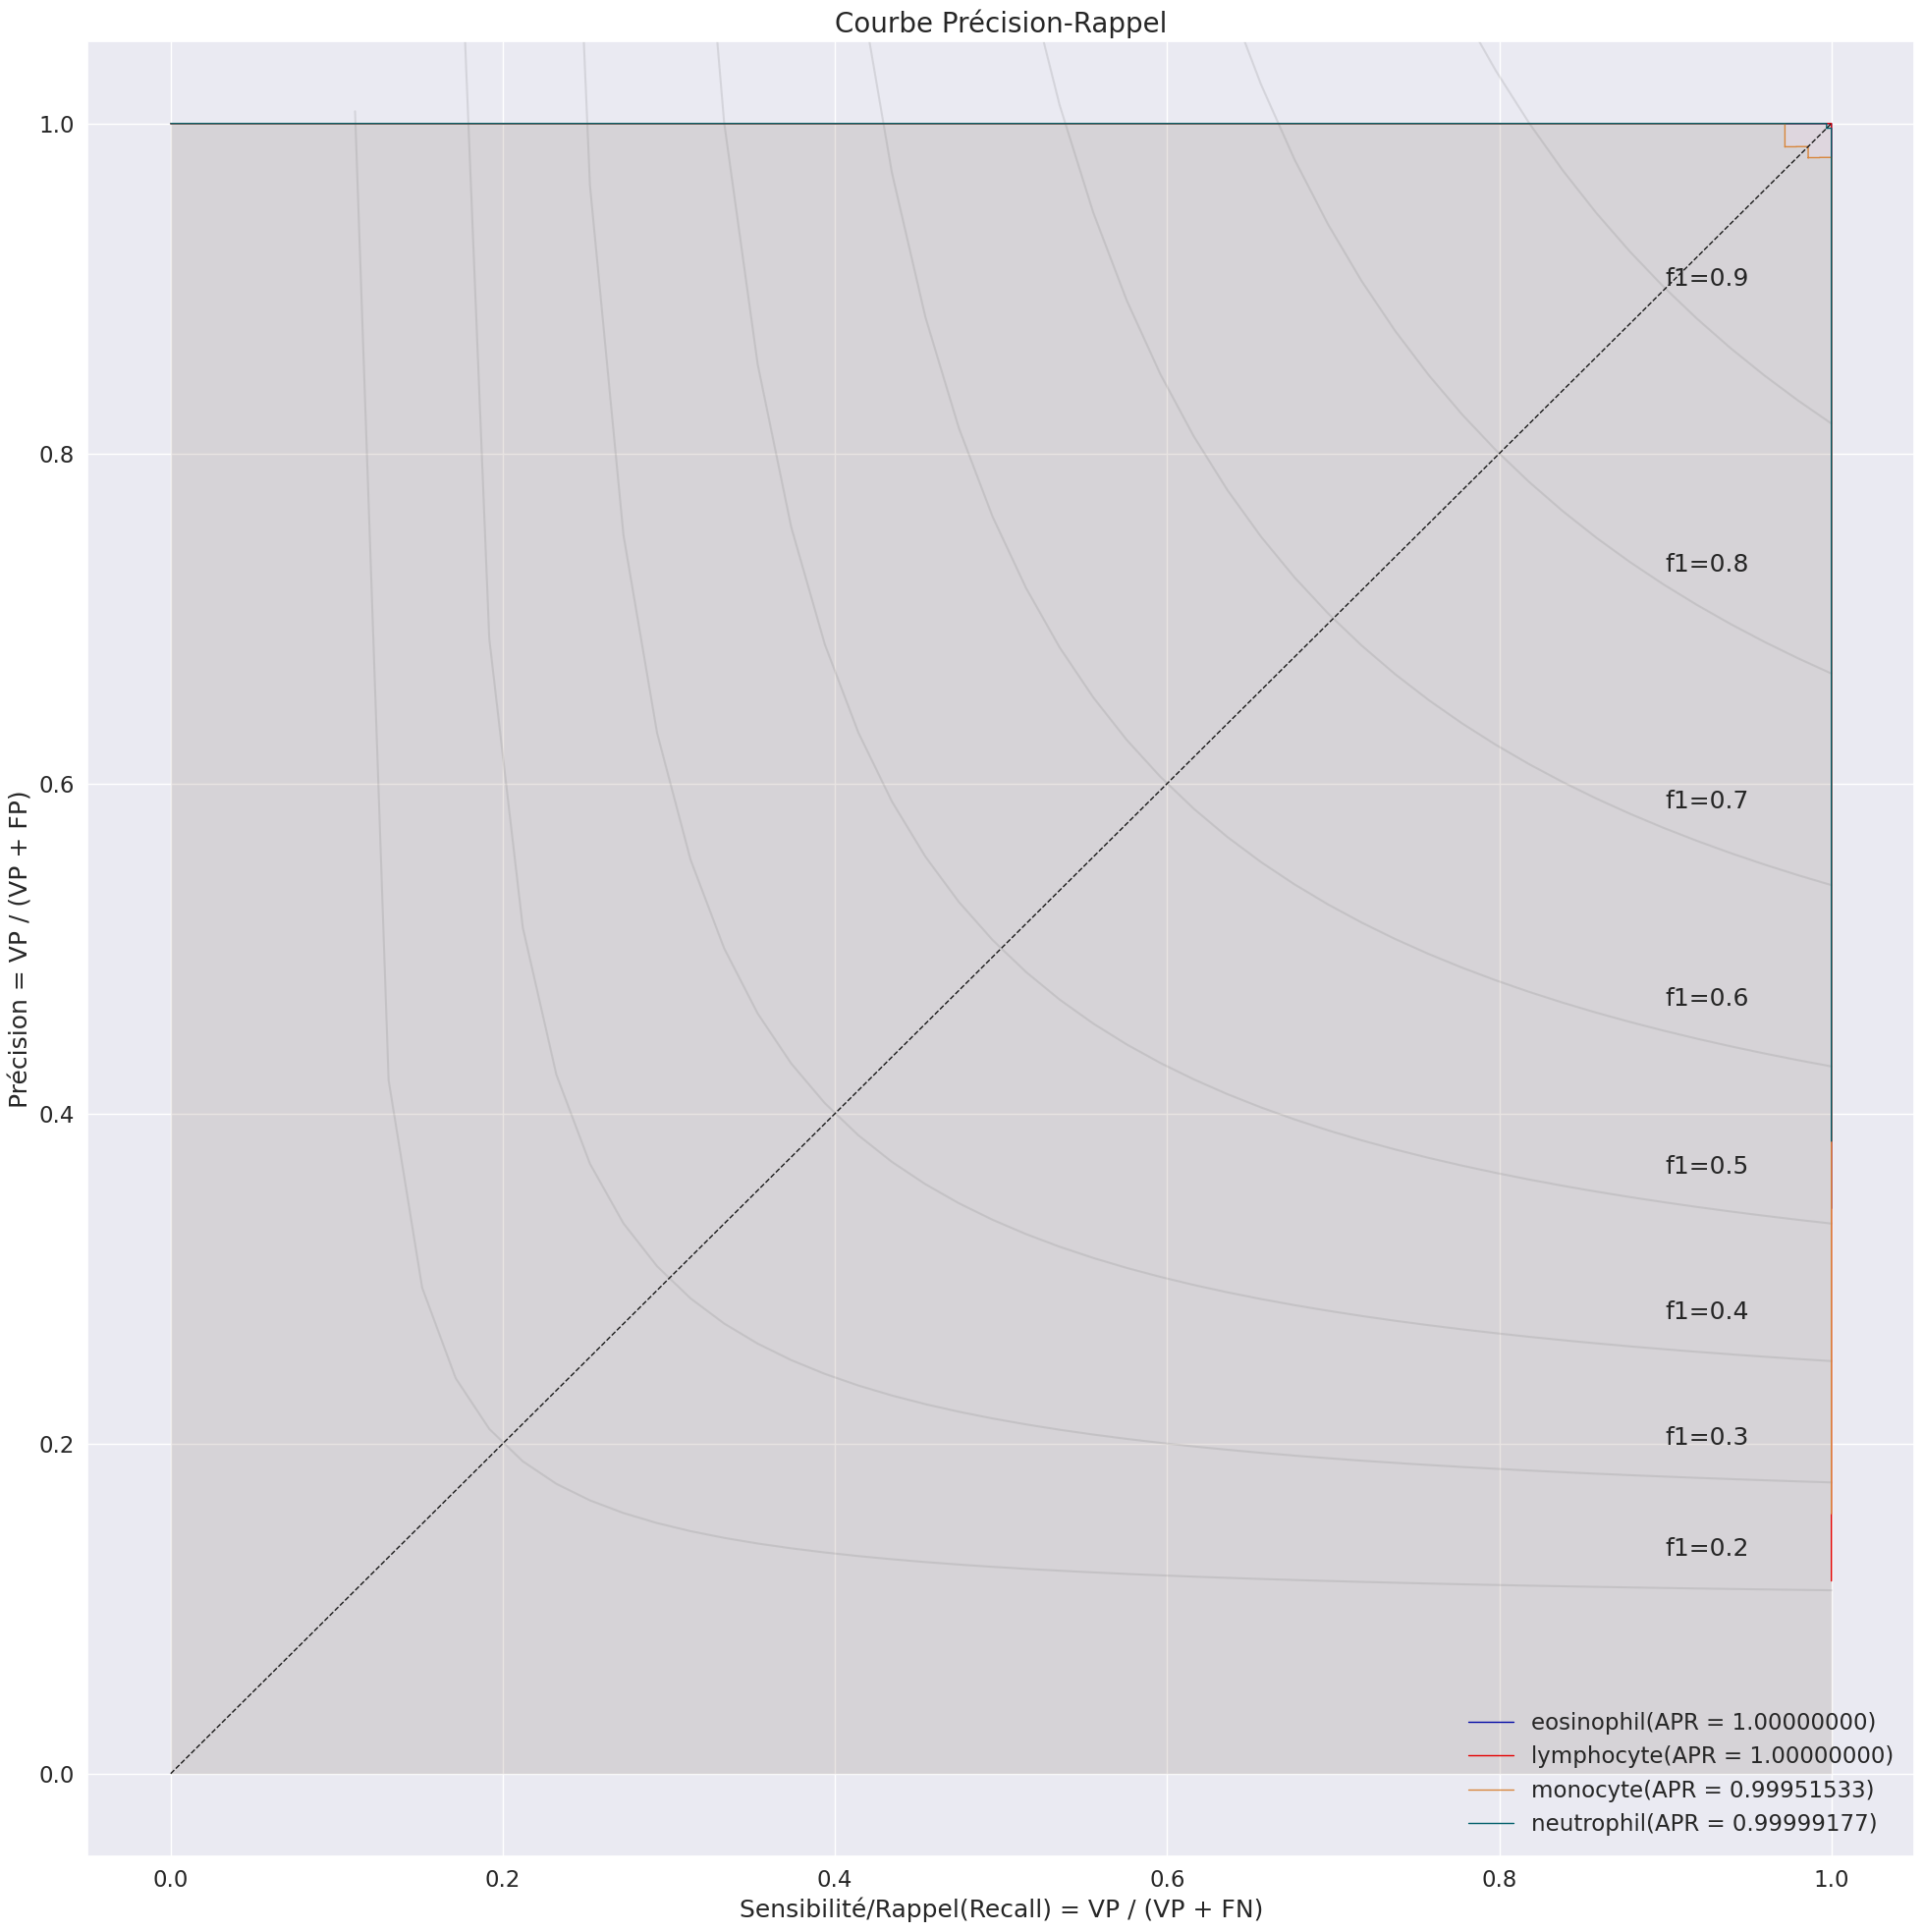

In [29]:
resultats = executeApprentissageChoixClassifieurs(
                                                  model,
                                                  X_test=images,
                                                  y_test=labels,
                                                  label_dict=dictLabels,
                                                  palette=palette, 
                                                  repertoireEnregistrement=repertoireEnregistrement,    
                                                  nom_essai = f'{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}',
                                                 );

resultats.to_parquet(os.path.join(repertoireSauvegardes,f'resultats-{nomModel}-bs{batch_size:02d}-epochs{epochs:03d}.gzip'),compression='gzip', engine='pyarrow')

resultats